# Import Statements

In [67]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.datasets import fetch_openml
from sklearn import metrics
from sklearn import model_selection
from sklearn import linear_model

import seaborn as sns

from sklearn.neighbors import KNeighborsClassifier


# Task 1: Linear Regression

In [68]:
boston = fetch_openml(name='boston', version=1, as_frame=True)

boston_data = boston.frame
X = boston.data
y = boston.target

X_rm = X[['RM']]

X_train, X_test, y_train, y_test = model_selection.train_test_split(X_rm, y, test_size=0.2, random_state=42)
model = linear_model.LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)


print(f'Mean Squared Error: {metrics.mean_squared_error(y_test, y_pred)}')
print(f'R^2 Score: {metrics.r2_score(y_test, y_pred)}')

Mean Squared Error: 46.144775347317264
R^2 Score: 0.3707569232254778


# Task 2: Regularization

## a.

Cost function (MSE): 24.48
R squared: 0.6662


Text(0, 0.5, 'predicted')

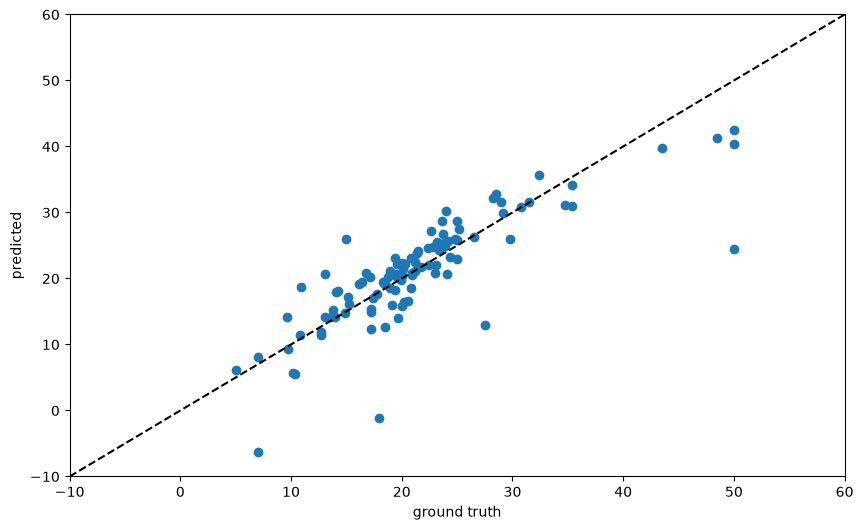

In [69]:
Xrig_train, Xrig_test, yrig_train, yrig_test = model_selection.train_test_split(X, y, test_size=0.2, random_state=42)

ridge_model = linear_model.Ridge()

ridge_model.fit(Xrig_train, yrig_train)

y_ridge_pred = ridge_model.predict(Xrig_test.astype(float))

print(f'Cost function (MSE): {metrics.mean_squared_error(yrig_test, y_ridge_pred):.2f}')
print(f'R squared: {metrics.r2_score(yrig_test, y_ridge_pred):.4f}') 


plt.figure(figsize=(10, 6))
plt.plot(yrig_test, y_ridge_pred, 'o')
plt.plot([-10, 60], [-10, 60], 'k--')
plt.axis([-10, 60, -10, 60])
plt.xlabel('ground truth')
plt.ylabel('predicted')


In [70]:
Xlasso_train, Xlasso_test, ylasso_train, ylasso_test = model_selection.train_test_split(X, y, test_size=0.2, random_state=42)

lasso_model = linear_model.Lasso()

lasso_model.fit(Xlasso_train, ylasso_train)

y_lasso_pred = lasso_model.predict(Xlasso_test.astype(float))

print(f'Cost function (MSE): {metrics.mean_squared_error(ylasso_test, y_lasso_pred):.2f}')
print(f'R squared: {metrics.r2_score(ylasso_test, y_lasso_pred):.4f}') 

Cost function (MSE): 24.41
R squared: 0.6671


## b.

In [71]:
import pandas as pd
coef_df = pd.DataFrame({
    'feature': boston_data.columns[:-1],  
    'ridge': ridge_model.coef_,
    'lasso': lasso_model.coef_
})
print(coef_df)

    feature     ridge     lasso
0      CRIM -0.109234 -0.076609
1        ZN  0.032271  0.028501
2     INDUS  0.007498 -0.000000
3      CHAS  2.545470  0.000000
4       NOX -9.537952 -0.000000
5        RM  4.464505  1.630489
6       AGE -0.012191  0.016395
7       DIS -1.338700 -0.630858
8       RAD  0.248882  0.219654
9       TAX -0.011475 -0.012286
10  PTRATIO -0.828604 -0.708582
11        B  0.012642  0.011181
12    LSTAT -0.523833 -0.747107



Ridge had a higher MSE than Lasso but a lower R-squared.

Lasso zeroed out INDUS, CHAS, and NOX, and Ridge has a higher MSE than Lasso and a lower R-squared than Lasso. This is because L1 has its corners on the axes, so the optimum lands on an axis, whereas for L2 the optimum stays off the axis, so it's non-zero. L1's penalty is a constant magnitude, and L2 is proportional to the weight itself.

## c. 

Mean Absolute Error



formula: $$\text{MAE} = \frac{1}{n}\sum_{i=1}^{n} |y_i - \hat{y}_i|$$
__why__: it treats all errors equally regardless of their direction and provides results in the same unit as the target variable.

## d.

Adjusted r squared

formula: $$R^2_{\text{adj}} = 1 - \left(\frac{(1-R^2)(n-1)}{n-k-1}\right)$$



# Task 3: Logistic Regression as a Classifier

In [72]:
iris = fetch_openml(name='iris', version=1, as_frame=True)
iris_data = iris.frame

X_iris = iris_data.drop('class', axis=1)
y_iris = iris_data['class']

X_iris_train, X_iris_test, y_iris_train, y_iris_test = model_selection.train_test_split(
    X_iris, y_iris, test_size=0.2, random_state=42
)

iris_model = linear_model.LogisticRegression(max_iter=100)
iris_model.fit(X_iris_train, y_iris_train)

y_iris_pred = iris_model.predict(X_iris_test)

print(metrics.classification_report(y_iris_test, y_iris_pred))

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00         9
 Iris-virginica       1.00      1.00      1.00        11

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



In [73]:
print(iris_data.head(5))

   sepallength  sepalwidth  petallength  petalwidth        class
0          5.1         3.5          1.4         0.2  Iris-setosa
1          4.9         3.0          1.4         0.2  Iris-setosa
2          4.7         3.2          1.3         0.2  Iris-setosa
3          4.6         3.1          1.5         0.2  Iris-setosa
4          5.0         3.6          1.4         0.2  Iris-setosa


# Task 4: Scikit k-NN

In [74]:
X_sepals = iris_data[['sepallength', 'sepalwidth']]

sepal_neighbor_model = KNeighborsClassifier(n_neighbors=3)
sepal_neighbor_model.fit(X_sepals, y_iris)

y_sepal_pred = sepal_neighbor_model.predict(X_sepals)
print(metrics.classification_report(y_iris, y_sepal_pred))

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        50
Iris-versicolor       0.80      0.74      0.77        50
 Iris-virginica       0.76      0.82      0.79        50

       accuracy                           0.85       150
      macro avg       0.85      0.85      0.85       150
   weighted avg       0.85      0.85      0.85       150



# Task 5: Logistic again

In [75]:
from sklearn.datasets import load_breast_cancer

consolidated_breast_cancer = load_breast_cancer(as_frame=True)
breast_cancer = load_breast_cancer(return_X_y=True, as_frame=True)


X = breast_cancer[0]
y = breast_cancer[1]

consolidated_breast_cancer.frame.head(5)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


## a.

<Axes: xlabel='mean perimeter', ylabel='mean area'>

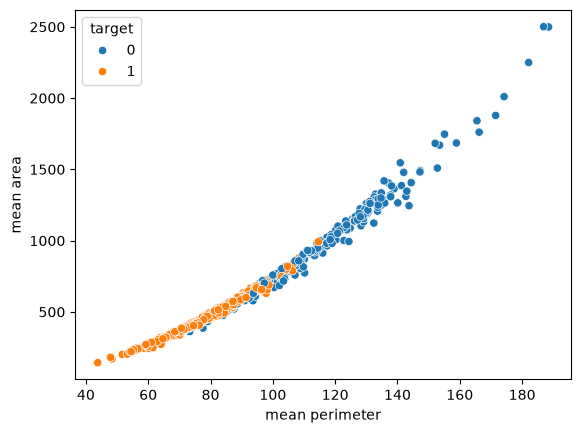

In [76]:
sns.scatterplot(data=consolidated_breast_cancer.frame, x='mean perimeter', y='mean area', hue='target')

## b.

Although mean area and mean perimeter show a clear clustering of class 0 at low values on both axes and class 1 clustering on the higher end of the axes, which suggests good predictive power, mean perimeter and mean area measure basically the size of the tumour cell nucleus, so they are related to each other, which may be multicollinearity. Therefore, the mean perimeter may be more useful if the mean area is not considered and vice versa.

## c.

<Axes: xlabel='mean smoothness', ylabel='mean area'>

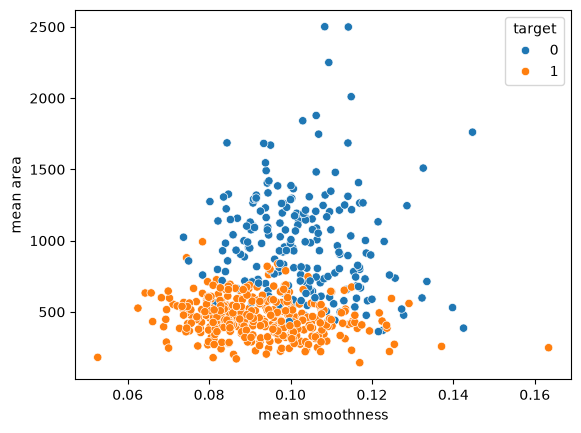

In [77]:
sns.scatterplot(data=consolidated_breast_cancer.frame, x='mean smoothness', y='mean area', hue='target')

## d.

Yes, the features are useful because, unlike mean area and mean perimeter, this shows clustering without redundancy, as there seems to be lower multicollinearity. Class 1 tends to have a lower mean area and mean smoothness; therefore, the pair distinguishes between tumour classes, whereas mean area and mean perimeter are mathematically related. 

## e.

Best pair: ('mean radius', 'worst perimeter'), F1: 0.9793


<Axes: xlabel='mean radius', ylabel='worst perimeter'>

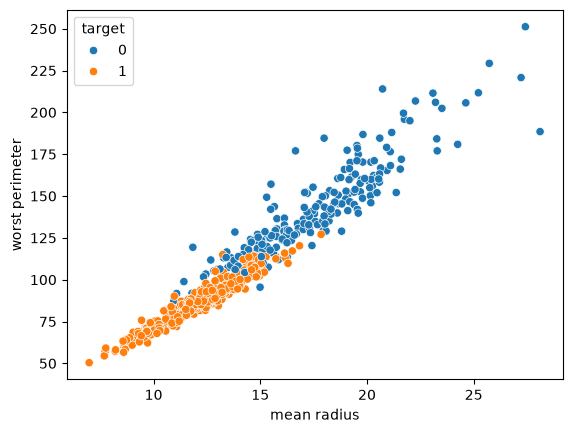

In [78]:
from itertools import combinations


X_train, X_test, y_train, y_test = model_selection.train_test_split(
    X, y, test_size=0.2, random_state=42
)

best_score = -1
best_pair = None

for f1_name, f2_name in combinations(X.columns, 2):
    model = linear_model.LogisticRegression(max_iter=10000)
    model.fit(X_train[[f1_name, f2_name]], y_train)
    preds = model.predict(X_test[[f1_name, f2_name]])
    score = metrics.f1_score(y_test, preds)
    if score > best_score:
        best_score = score
        best_pair = (f1_name, f2_name)

print(f"Best pair: {best_pair}, F1: {best_score:.4f}")



sns.scatterplot(data=consolidated_breast_cancer.frame, x=best_pair[0], y=best_pair[1], hue='target')

## f.

Precision: 0.9595
Recall: 1.0000
F1 Score: 0.9793


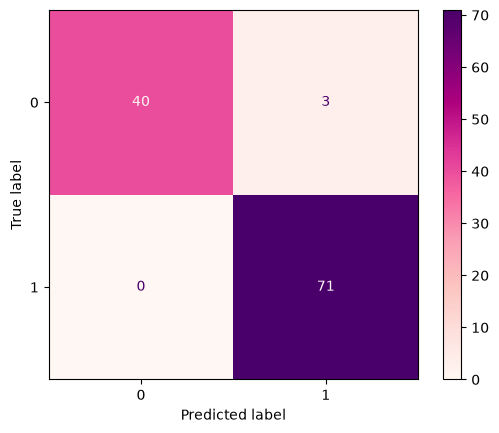

In [79]:
best_model = linear_model.LogisticRegression(max_iter=10000)
best_model.fit(X_train[[best_pair[0], best_pair[1]]], y_train)

metrics.ConfusionMatrixDisplay.from_estimator(
    best_model,
    X_test[[best_pair[0], best_pair[1]]],
    y_test,
    cmap=plt.cm.RdPu
)

tn,fp,fn,tp = metrics.confusion_matrix(y_test, best_model.predict(X_test[[best_pair[0], best_pair[1]]])).ravel()


precision = tp / (tp + fp)
recall = tp / (tp + fn)
f1 = 2 * (precision * recall) / (precision + recall)

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")



## g.

Recall is more important than precision and F1 because it measures everything positive, how many were caught. In the breast cancer context, it's more important to catch the positive (malignant tumours) so patients can be treated appropriately when the diagnosis is given. It's more costly to have false negatives in this situation, as they result in patients not receiving treatment when they should.